<a href="https://colab.research.google.com/github/shubhangiM2007/MDM_Tasks_EE522/blob/main/Task_10_EE522.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np

In [ ]:
class Layer:
    def __init__(self):
        self.input = None
        self.output = None

    def forward(self, input):
        pass

    def backward(self,output_gradient, learning_rate):
        pass

In [ ]:
class Dense(Layer):
    def __init__(self, input_size, output_size):
        self.weights = np.random.randn(output_size, input_size)
        self.bias = np.random.randn(output_size, 1)

    def forward(self, input):
        self.input = input
        return np.dot(self.weights, self.input) + self.bias

    def backward(self, output_gradient, input_gradient):
        weights_gradient = np.dot(output_gradient, self.input.T)
        input_gradient = np.dot(self.weights.T, output_gradient)

        self.weights -= learning_rate * weights_gradient
        self.bias -= learning_rate * output_gradient

        return input_gradient

In [ ]:
def mse(y_true, y_pred):
    return np.mean(np.power(y_true - y_pred, 2))

def mse_prime(y_true, y_pred):
    return 2 * (y_pred - y_true) / np.size(y_true)

In [ ]:
class Activation(Layer):
    def __init__(self, activation, activation_prime):
        self.activation = activation
        self.activation_prime = activation_prime

    def forward(self, input):
        self.input = input
        return self.activation(self.input)

    def backward(self, output_gradient, learning_rate):
        return np.multiply(output_gradient, self.activation_prime(self.input))

In [ ]:
class Tanh(Activation):
    def __init__(self):
        def tanh(x):
            return np.tanh(x)

        def tanh_prime(x):
            return 1- np.tanh(x) ** 2

        super().__init__(tanh, tanh_prime)


class Sigmoid(Activation):
    def __init__(self):
        def sigmoid(x):
            return 1 / (1 + np.exp(-x))

        def sigmoid_prime(x):
            s = sigmoid(x)
            return s * (1-s)

        super().__init__(sigmoid, sigmoid_prime)

In [ ]:
import math

In [ ]:
class Linear(Activation):
    def __init__(self):
        def linear(x):
            return x

        def linear_prime(x):
            return 1

        super().__init__(linear, linear_prime)

**4A**

In [ ]:
X = np.linspace(-3,3,61)
Y = [math.sin(p) for p in X]

network = [
    Dense(1, 10),
    Tanh(),
    Dense(10, 1),
    Linear()
]

epochs = 50
learning_rate = 0.1
errorlist = []

for e in range(epochs):
    error = 0
    for x,y in zip(X,Y):
        output = x
        for layer in network:
            output=layer.forward(output)
        error += mse(y,output)
        grad = mse_prime(y,output)

        for layer in reversed(network):
            grad = layer.backward(grad, learning_rate)
    error /= len(X)
    print(f"{e + 1}/({epochs}, error={error}")
    errorlist.append(error)

1/(50, error=11.298694438332909
2/(50, error=0.09754447408350667
3/(50, error=0.008273836584917071
4/(50, error=0.03403618454015487
5/(50, error=0.07684766647412367
6/(50, error=0.07182221113122736
7/(50, error=0.057563827385177645
8/(50, error=0.05461949615538057
9/(50, error=0.046448561799565795
10/(50, error=0.03569622100892121
11/(50, error=0.026217297627612123
12/(50, error=0.018921573538280747
13/(50, error=0.013703985130073459
14/(50, error=0.010132933750317652
15/(50, error=0.007750057481985316
16/(50, error=0.006222317641710591
17/(50, error=0.005343621803644143
18/(50, error=0.004961508349375149
19/(50, error=0.0049176847606199215
20/(50, error=0.005079026892093422
21/(50, error=0.0054027364055873285
22/(50, error=0.00593777971968668
23/(50, error=0.006766580458010718
24/(50, error=0.007932372784913886
25/(50, error=0.00939657260322963
26/(50, error=0.011045262023217522
27/(50, error=0.012727297701423891
28/(50, error=0.014296643376046757
29/(50, error=0.015643948307933246
30

In [ ]:
actual_Y = []
for x in X:
    output = x
    for layer in network:
        output=layer.forward(output)
    actual_Y.append(output[0])
    print(output)

[[-0.74410917]]
[[-0.75862159]]
[[-0.77355127]]
[[-0.78883437]]
[[-0.80439817]]
[[-0.82016046]]
[[-0.83602786]]
[[-0.85189281]]
[[-0.86762857]]
[[-0.88308117]]
[[-0.89805773]]
[[-0.91230955]]
[[-0.92550866]]
[[-0.93721614]]
[[-0.94684039]]
[[-0.95358419]]
[[-0.95638081]]
[[-0.9538229]]
[[-0.9440952]]
[[-0.9249346]]
[[-0.8936604]]
[[-0.8473415]]
[[-0.78318481]]
[[-0.69921461]]
[[-0.59522849]]
[[-0.47384106]]
[[-0.34120974]]
[[-0.20690671]]
[[-0.08245905]]
[[0.02169802]]
[[0.10056386]]
[[0.15843729]]
[[0.20869103]]
[[0.26740962]]
[[0.34494407]]
[[0.44205246]]
[[0.55200401]]
[[0.66496068]]
[[0.7714159]]
[[0.86392156]]
[[0.93756801]]
[[0.98979069]]
[[1.01988439]]
[[1.02844706]]
[[1.01687876]]
[[0.98699701]]
[[0.9407858]]
[[0.88026683]]
[[0.8074653]]
[[0.72443446]]
[[0.63330092]]
[[0.53629531]]
[[0.43574123]]
[[0.33399087]]
[[0.23331406]]
[[0.13576496]]
[[0.04305844]]
[[-0.0435148]]
[[-0.12311909]]
[[-0.19535087]]
[[-0.26017553]]


In [ ]:
import matplotlib.pyplot as plt

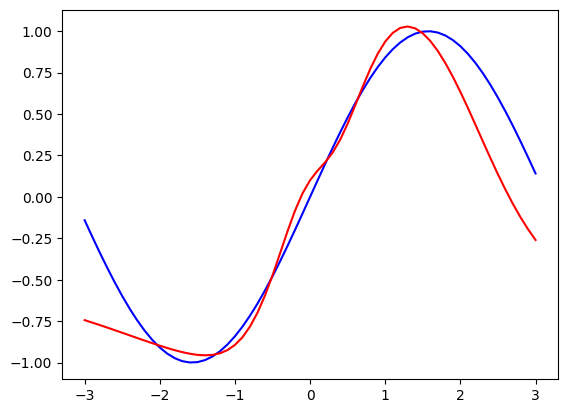

In [ ]:
plt.plot(X,Y,color='blue')
plt.plot(X, actual_Y,color='red')
plt.show()

**4B**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

In [ ]:
def preprocess_data(x, y, limit):
        x = x.reshape(x.shape[0], 28 * 28, 1)
        x = x.astype("float32")/255

        y = to_categorical(y)
        y = y.reshape(y.shape[0], 10, 1)

        return x[:limit], y[:limit]

In [ ]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train, y_train = preprocess_data(x_train, y_train, 10000)
x_test, y_test = preprocess_data(x_test, y_test, 20)

In [ ]:
network = [
    Dense(784, 80),
    Sigmoid(),
    Dense(80, 10),
    Sigmoid()
]

epochs = 50
learning_rate = 0.1
errorlist = []

for e in range(epochs):
    error = 0
    for x,y in zip(x_train,y_train):
        output = x
        for layer in network:
            output=layer.forward(output)
        error += mse(y,output)
        grad = mse_prime(y,output)

        for layer in reversed(network):
            grad = layer.backward(grad, learning_rate)
    error /= len(x)
    print(f"{e + 1}/({epochs}, error={error}")
    errorlist.append(error)

1/(50, error=1.302448765634828
2/(50, error=1.0265916323821207
3/(50, error=0.9511989466906003
4/(50, error=0.8954685713395022
5/(50, error=0.8620514505919421
6/(50, error=0.8335018931060999
7/(50, error=0.7995956201945825
8/(50, error=0.7577863882697632
9/(50, error=0.7235758454475747
10/(50, error=0.7019035227549825
11/(50, error=0.6839333087190256
12/(50, error=0.6687492635603745
13/(50, error=0.6558762819721038
14/(50, error=0.6306723160198685
15/(50, error=0.5607096569468779
16/(50, error=0.5263704210601802
17/(50, error=0.49244831333474764
18/(50, error=0.4674964644303717
19/(50, error=0.45116114842907745
20/(50, error=0.43926652263481836
21/(50, error=0.4299992976483255
22/(50, error=0.42062652433544867
23/(50, error=0.3951280913048085
24/(50, error=0.35732563948365226
25/(50, error=0.3307245868450316
26/(50, error=0.3008397566404503
27/(50, error=0.2752776253541789
28/(50, error=0.25640445148174995
29/(50, error=0.24177414384948354
30/(50, error=0.22992082051913665
31/(50, erro

In [ ]:
def predict(network, input):
    output = input
    for layer in network:
        output = layer.forward(output)
    return output

In [ ]:
#!pip install simple-colors

In [ ]:
import simple_colors

In [ ]:
correct = 0

for x,y in zip(x_test, y_test):
    output = predict(network ,x)
    if np.argmax(output) == np.argmax(y):
        correct += 1
        print('pred:', np.argmax(output), '\ttrue:', np.argmax(y))
    else:
        print(simple_colors.red(f'pred: {np.argmax(output)} \ttrue: {np.argmax(y)}'))

accuracy = correct / len(y_test)
print(f"Accuracy: {accuracy}")
print(f"Correct: {correct}")

pred: 7 	true: 7
pred: 2 	true: 2
pred: 1 	true: 1
pred: 0 	true: 0
pred: 4 	true: 4
pred: 1 	true: 1
pred: 4 	true: 4
pred: 9 	true: 9
pred: 6 	true: 5
pred: 9 	true: 9
pred: 0 	true: 0
pred: 0 	true: 6
pred: 9 	true: 9
pred: 0 	true: 0
pred: 1 	true: 1
pred: 5 	true: 5
pred: 9 	true: 9
pred: 7 	true: 7
pred: 3 	true: 3
pred: 4 	true: 4
Accuracy: 0.9
Correct: 18


In [ ]:
error = errorlist
X = list(range(1,len(errorlist) + 1))

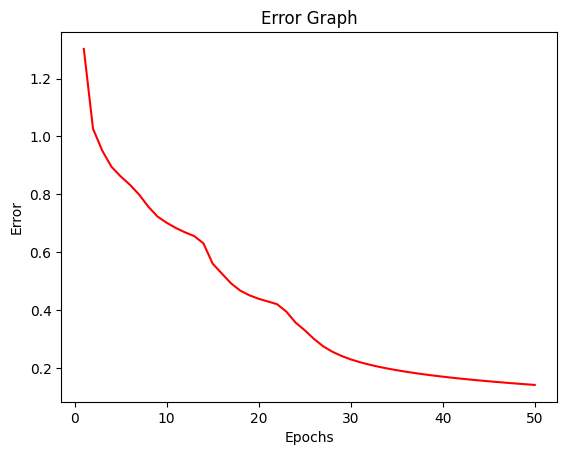

In [ ]:
plt.plot(X, error, color='r')
plt.xlabel("Epochs")
plt.ylabel("Error")
plt.title("Error Graph")
plt.show()